# Generative Project — Interactive Demo Notebook

**IE 7615 Group 8 — Spring 2026**

Select an image, choose a model and decoding parameters, then generate and evaluate captions.

**Requirements:** Run from the project root with the `.venv` activated.
```bash
source .venv/bin/activate
jupyter notebook demo/demo.ipynb
```

---
## Cell 1 — Imports and setup

In [1]:
import os, sys, re, math, time
from pathlib import Path
from dataclasses import dataclass
from typing import Optional

import torch
import torch.nn as nn
import numpy as np
from PIL import Image
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

# ── Project root (one level up from demo/)
DEMO_DIR     = Path().resolve()
PROJECT_ROOT = DEMO_DIR.parent if DEMO_DIR.name == 'demo' else DEMO_DIR
sys.path.insert(0, str(PROJECT_ROOT))

# ── Offline mode if HF models are already cached
_HF_CACHE = Path.home() / '.cache' / 'huggingface' / 'hub'
def _cached(model_id):
    snap = _HF_CACHE / ('models--' + model_id.replace('/', '--')) / 'snapshots'
    return snap.exists() and any(s.is_dir() for s in snap.iterdir())

if _cached('openai/clip-vit-base-patch32') and _cached('gpt2'):
    os.environ['TRANSFORMERS_OFFLINE'] = '1'

from transformers import CLIPModel, CLIPProcessor, GPT2LMHeadModel, GPT2Tokenizer

# ── Device
if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = 'mps'
elif torch.cuda.is_available():
    DEVICE = 'cuda'
else:
    DEVICE = 'cpu'
print(f'Device: {DEVICE}')

# ── Constants
CLIP_MODEL  = 'openai/clip-vit-base-patch32'
GPT2_MODEL  = 'gpt2'
CKPTS = {
    'Frozen': PROJECT_ROOT / 'outputs' / 'checkpoints' / 'best_model.pt',
    'FT-4L':  PROJECT_ROOT / 'outputs' / 'checkpoints' / 'best_model_finetuned.pt',
    'LoRA':   PROJECT_ROOT / 'outputs' / 'checkpoints' / 'best_model_lora.pt',
}
print('Project root:', PROJECT_ROOT)
for k, p in CKPTS.items():
    print(f'  {k}: {"OK" if p.exists() else "NOT FOUND"}')

Device: mps
Project root: /Users/kevin/Documents/GitHub/Python/VESKL/11.DAE/NEU/NEU_IE7615/Prj/Generative_Project
  Frozen: OK
  FT-4L: OK
  LoRA: OK


---
## Cell 2 — Model architecture and loaders

In [2]:
import types

# ── TrainingConfig stub for unpickling old checkpoints
@dataclass
class TrainingConfig:
    clip_model_name: str = CLIP_MODEL
    gpt2_model_name: str = GPT2_MODEL
    clip_embedding_dim: int = 512
    gpt2_embedding_dim: int = 768
    prefix_length: int = 10
    max_token_length: int = 50
    learning_rate: float = 5e-4
    batch_size: int = 16
    epochs: int = 20
    warmup_ratio: float = 0.1
    weight_decay: float = 0.01
    beam_width: int = 5
    nucleus_top_p: float = 0.9
    nucleus_temperature: float = 0.8
    early_stopping_patience: int = 3
    log_interval: int = 50
    seed: int = 42
    device: str = DEVICE
    project_root: str = str(PROJECT_ROOT)
    data_raw_dir: str = ''
    data_processed_dir: str = ''
    embeddings_dir: str = ''
    checkpoints_dir: str = ''
    samples_dir: str = ''

_main = sys.modules.get('__main__', types.ModuleType('__main__'))
if not hasattr(_main, 'TrainingConfig'):
    _main.TrainingConfig = TrainingConfig
    sys.modules['__main__'] = _main

# ── Architecture (must match training code exactly)
class ProjectionHead(nn.Module):
    def __init__(self, clip_dim=512, gpt2_dim=768, prefix_length=10):
        super().__init__()
        self.prefix_length = prefix_length
        self.gpt2_dim = gpt2_dim
        h = gpt2_dim * prefix_length
        self.projection = nn.Sequential(
            nn.Linear(clip_dim, h), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(h, h), nn.LayerNorm(h),
        )
    def forward(self, x):
        return self.projection(x).view(-1, self.prefix_length, self.gpt2_dim)


_tokenizer = None  # shared tokenizer, loaded once

class ClipCaptionModel(nn.Module):
    def __init__(self, tokenizer, prefix_length=10):
        super().__init__()
        self.prefix_length = prefix_length
        self.projection = ProjectionHead(512, 768, prefix_length)
        self.gpt2 = GPT2LMHeadModel.from_pretrained(GPT2_MODEL)
        self.gpt2.resize_token_embeddings(len(tokenizer))

    @torch.no_grad()
    def generate(self, emb, strategy='beam', num_beams=5, temperature=0.5,
                 top_p=0.9, max_new_tokens=30):
        self.eval()
        tok = _tokenizer
        if emb.dim() == 1:
            emb = emb.unsqueeze(0)
        emb = emb.to(next(self.parameters()).device)
        prefix = self.projection(emb)
        kwargs = dict(
            inputs_embeds=prefix, max_new_tokens=max_new_tokens, min_new_tokens=5,
            pad_token_id=tok.pad_token_id, eos_token_id=tok.eos_token_id,
            no_repeat_ngram_size=4, forced_eos_token_id=tok.eos_token_id,
        )
        if strategy == 'greedy':
            kwargs.update(do_sample=False, repetition_penalty=1.5)
        elif strategy == 'beam':
            kwargs.update(do_sample=False, num_beams=num_beams,
                          early_stopping=True, no_repeat_ngram_size=2, length_penalty=1.0)
        elif strategy == 'nucleus':
            kwargs.update(do_sample=True, top_p=top_p, temperature=temperature,
                          top_k=0, repetition_penalty=1.3)
        ids = self.gpt2.generate(**kwargs)
        raw = tok.decode(ids[0], skip_special_tokens=True).strip()
        m = re.search(r'[.!?](?=\s|$)', raw)
        return raw[:m.end()].strip() if m else raw


def load_checkpoint(ckpt_path):
    """Load a ClipCaptionModel from .pt file. Handles Frozen, FT-4L, LoRA."""
    global _tokenizer
    if _tokenizer is None:
        _tokenizer = GPT2Tokenizer.from_pretrained(GPT2_MODEL)
        _tokenizer.pad_token = _tokenizer.eos_token

    raw   = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    state = raw.get('model_state_dict', raw) if isinstance(raw, dict) else raw
    state = {k.replace('module.', ''): v for k, v in state.items()}

    # LoRA checkpoint: PEFT stores with 'base_model.model.' prefix
    if any(k.startswith('base_model.model.') for k in state):
        clean = {}
        for k, v in state.items():
            k2 = k.replace('base_model.model.', '')
            k2 = k2.replace('.base_layer.weight', '.weight')
            if 'lora_A' in k2 or 'lora_B' in k2:
                continue
            clean[k2] = v
        state = clean

    model = ClipCaptionModel(_tokenizer).cpu()
    model.load_state_dict(state, strict=False)
    return model.to(DEVICE)

print('Architecture defined — ready to load checkpoints.')

Architecture defined — ready to load checkpoints.


---
## Cell 3 — Load CLIP encoder and model cache

In [3]:
print('Loading CLIP ViT-B/32 ...')
clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL)
clip_model     = CLIPModel.from_pretrained(CLIP_MODEL).to(DEVICE)
clip_model.eval()
print('CLIP loaded.')

# Cache loaded caption models to avoid reloading each run
_model_cache: dict = {}

def get_model(name: str):
    if name not in _model_cache:
        ckpt = CKPTS[name]
        if not ckpt.exists():
            raise FileNotFoundError(f'Checkpoint not found: {ckpt}')
        print(f'Loading {name} ...')
        _model_cache[name] = load_checkpoint(ckpt)
        _model_cache[name].eval()
        print(f'{name} loaded.')
    return _model_cache[name]


def encode_image(pil_img: Image.Image) -> torch.Tensor:
    """Return L2-normalised 512-d CLIP embedding for a PIL image."""
    inputs = clip_processor(images=pil_img, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        feat = clip_model.vision_model(**inputs)
        emb  = clip_model.visual_projection(feat.pooler_output)
        emb  = emb / emb.norm(dim=-1, keepdim=True)
    return emb.cpu().squeeze(0)


def normalize_preview(pil_img: Image.Image) -> Image.Image:
    """
    Apply CLIP preprocessing visually:
    1. Resize shortest side to 224 (preserving aspect ratio)
    2. Center-crop to 224x224
    Returns the cropped PIL image (not normalized tensor).
    """
    w, h = pil_img.size
    scale = 224 / min(w, h)
    new_w, new_h = round(w * scale), round(h * scale)
    img = pil_img.resize((new_w, new_h), Image.BICUBIC)
    left = (new_w - 224) // 2
    top  = (new_h - 224) // 2
    return img.crop((left, top, left + 224, top + 224))


print('Helpers ready.')

Loading CLIP ViT-B/32 ...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIP loaded.
Helpers ready.


---
## Cell 4 — Metric helpers

In [4]:
import math, re
from collections import Counter

# ── Reference-free metrics ────────────────────────────────────────────────────

def clip_score(pil_img: Image.Image, caption: str) -> float:
    """CLIPScore = max(cos_sim(image_emb, text_emb), 0) * 2.5  (range ~0-100)."""
    img_inputs = clip_processor(images=pil_img, return_tensors='pt').to(DEVICE)
    txt_inputs = clip_processor(text=[caption], return_tensors='pt',
                                padding=True, truncation=True, max_length=77).to(DEVICE)
    with torch.no_grad():
        i_feat = clip_model.vision_model(**img_inputs)
        i_emb  = clip_model.visual_projection(i_feat.pooler_output)
        i_emb  = i_emb / i_emb.norm(dim=-1, keepdim=True)

        # Text encoder needs to run on CPU to avoid MPS unsupported ops
        clip_model.text_model.to('cpu')
        clip_model.text_projection.to('cpu')
        txt_enc = {k: v.to('cpu') for k, v in txt_inputs.items()}
        t_feat  = clip_model.text_model(**txt_enc)
        t_emb   = clip_model.text_projection(t_feat.pooler_output)
        t_emb   = t_emb / t_emb.norm(dim=-1, keepdim=True)
        clip_model.text_model.to(DEVICE)
        clip_model.text_projection.to(DEVICE)

        sim = (i_emb.cpu() * t_emb).sum().item()
    return round(max(0.0, sim) * 100, 2)


def perplexity(caption: str) -> float:
    """GPT-2 perplexity of the caption (lower = more fluent)."""
    tok = _tokenizer
    model = get_model(list(CKPTS.keys())[0])  # use whichever is loaded
    ids = tok.encode(caption, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        loss = model.gpt2(ids, labels=ids).loss
    return round(math.exp(loss.item()), 2)


def grammar_score(caption: str) -> float:
    """Heuristic grammar score (0–100). Checks length, verb presence, repetition, URLs."""
    tokens = caption.lower().split()
    n = len(tokens)
    score = 100.0
    if n < 4:
        score -= 20
    verbs = {'is','are','was','were','has','have','playing','sitting','standing',
             'holding','walking','running','eating','looking','wearing','riding'}
    if not any(t in verbs for t in tokens):
        score -= 15
    if n > 2 and len(set(tokens)) / n < 0.6:
        score -= 10
    if any(re.search(r'http|www|\d{4,}', t) for t in tokens):
        score -= 25
    return round(max(0.0, min(100.0, score)), 1)


# ── Reference-based metrics ───────────────────────────────────────────────────

def _ngrams(tokens, n):
    return Counter(zip(*[tokens[i:] for i in range(n)]))


def bleu_n(hyp: str, refs: list[str], n: int) -> float:
    """Sentence BLEU-n with smoothing (add-1 on clipped count)."""
    h = hyp.lower().split()
    if len(h) < n:
        return 0.0
    hyp_ng  = _ngrams(h, n)
    clipped = 0
    for ref in refs:
        r = ref.lower().split()
        ref_ng = _ngrams(r, n)
        for gram, cnt in hyp_ng.items():
            clipped = max(clipped, min(cnt, ref_ng.get(gram, 0)))
    total   = max(1, sum(hyp_ng.values()))
    prec    = (clipped + 1) / (total + 1)   # add-1 smoothing
    # Brevity penalty
    ref_len = min(len(r.split()) for r in refs)
    bp = 1.0 if len(h) >= ref_len else math.exp(1 - ref_len / len(h))
    return round(bp * prec, 4)


def meteor_score(hyp: str, refs: list[str]) -> float:
    """Approximate METEOR via unigram F1 (no WordNet, suitable for quick eval)."""
    h_toks = set(hyp.lower().split())
    scores = []
    for ref in refs:
        r_toks = set(ref.lower().split())
        matched = len(h_toks & r_toks)
        if matched == 0:
            scores.append(0.0)
            continue
        p = matched / len(h_toks)
        r = matched / len(r_toks)
        f = 10 * p * r / (9 * p + r + 1e-9)
        scores.append(f)
    return round(max(scores), 4)


def rouge_l(hyp: str, refs: list[str]) -> float:
    """ROUGE-L: longest common subsequence F1."""
    def lcs(a, b):
        m, n = len(a), len(b)
        dp = [[0] * (n + 1) for _ in range(m + 1)]
        for i in range(1, m+1):
            for j in range(1, n+1):
                dp[i][j] = dp[i-1][j-1] + 1 if a[i-1] == b[j-1] else max(dp[i-1][j], dp[i][j-1])
        return dp[m][n]

    h = hyp.lower().split()
    scores = []
    for ref in refs:
        r = ref.lower().split()
        l = lcs(h, r)
        if l == 0:
            scores.append(0.0)
            continue
        p = l / len(h)
        rc = l / len(r)
        f = 2 * p * rc / (p + rc + 1e-9)
        scores.append(f)
    return round(max(scores), 4)


print('Metric helpers ready.')

Metric helpers ready.


---
## Cell 5 — Interactive demo UI

Upload an image, pick parameters, and click **Generate Caption**.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import io as _io

# ── State
_state = {'pil': None, 'emb': None, 'caption': None}

# ── Widgets
w_upload   = widgets.FileUpload(accept='image/*', multiple=False,
                                description='Upload Image', button_style='info')
w_model    = widgets.ToggleButtons(options=['Frozen','FT-4L','LoRA'],
                                   description='Model:', button_style='')
w_strategy = widgets.ToggleButtons(options=['beam','greedy','nucleus'],
                                   description='Strategy:', button_style='')
w_beams    = widgets.IntSlider(value=5, min=1, max=10, description='Beam width:',
                               continuous_update=False, style={'description_width':'100px'})
w_temp     = widgets.FloatSlider(value=0.5, min=0.1, max=1.5, step=0.1,
                                 description='Temperature:', continuous_update=False,
                                 style={'description_width':'100px'})
w_maxlen   = widgets.IntSlider(value=30, min=10, max=60, description='Max tokens:',
                                continuous_update=False, style={'description_width':'100px'})
w_btn      = widgets.Button(description='Generate Caption', button_style='success',
                            layout=widgets.Layout(width='200px'))
w_out      = widgets.Output()
w_img_out  = widgets.Output(layout=widgets.Layout(width='240px'))

# Show/hide beam width and temperature based on strategy
def _on_strategy(change):
    s = change['new']
    w_beams.layout.display = '' if s == 'beam' else 'none'
    w_temp.layout.display  = '' if s == 'nucleus' else 'none'
w_strategy.observe(_on_strategy, names='value')
_on_strategy({'new': w_strategy.value})

# Preview image on upload
def _on_upload(change):
    # Compatible with all ipywidgets versions and deduplicated against double-fire
    v = change.get('new') or w_upload.value
    if not v:
        return
    item = list(v.values())[0] if isinstance(v, dict) else v[0]
    raw  = item['content']
    # Deduplicate: observer fires twice on some ipywidgets/Jupyter builds
    h = hash(bytes(raw[:256]) if len(raw) >= 256 else bytes(raw))
    if h in _upload_seen:
        return
    _upload_seen.clear()
    _upload_seen.add(h)
    content = bytes(raw) if not isinstance(raw, (bytes, bytearray)) else raw
    pil = Image.open(_io.BytesIO(content)).convert('RGB')
    _state['pil']     = pil
    _state['emb']     = None
    _state['caption'] = None
    with w_img_out:
        clear_output(wait=True)
        orig = pil.copy()
        orig.thumbnail((224, 224))
        cropped  = normalize_preview(pil)
        combined = Image.new('RGB', (orig.width + 8 + 224, 224), (240, 240, 240))
        combined.paste(orig,    (0, 0))
        combined.paste(cropped, (orig.width + 8, 0))
        display(combined)
        print(f'Original: {pil.size}  |  CLIP-ready: 224x224')

_upload_seen = set()  # deduplicate — observer fires twice on some builds
w_upload.observe(_on_upload, names='value')

# Generate button handler
def _on_generate(b):
    with w_out:
        clear_output(wait=True)
        if _state['pil'] is None:
            print('Please upload an image first.')
            return

        model_name = w_model.value
        strategy   = w_strategy.value
        print(f'Model: {model_name}  |  Strategy: {strategy}')

        # Encode image
        if _state['emb'] is None:
            print('Encoding image with CLIP ...')
            _state['emb'] = encode_image(_state['pil'])

        # Load model
        print('Loading model ...')
        model = get_model(model_name)

        # Generate
        t0 = time.time()
        caption = model.generate(
            _state['emb'],
            strategy=strategy,
            num_beams=w_beams.value,
            temperature=w_temp.value,
            max_new_tokens=w_maxlen.value,
        )
        elapsed = time.time() - t0
        _state['caption'] = caption

        # Display result
        display(HTML(f"""
<div style='border-left:4px solid #0B6E4F;padding:10px 14px;margin:10px 0;background:#f4f8f6;border-radius:4px'>
  <b style='color:#0B6E4F'>Generated Caption</b>
  <p style='font-size:15px;margin:6px 0 0'><i>&ldquo;{caption}&rdquo;</i></p>
  <small style='color:#888'>Model: {model_name} | Strategy: {strategy} | {elapsed:.2f}s</small>
</div>
"""))

w_btn.on_click(_on_generate)

# ── Layout
param_box = widgets.VBox([
    widgets.HBox([w_model, w_strategy]),
    w_beams, w_temp, w_maxlen,
])

display(widgets.VBox([
    widgets.HTML('<h3 style="margin:4px 0">VisCaption — Interactive Demo</h3>'),
    widgets.HBox([w_upload, w_img_out]),
    param_box,
    w_btn,
    w_out,
]))

---
## Cell 6 — CLIP image normalization visualization

Shows the preprocessing steps applied before CLIP encoding.

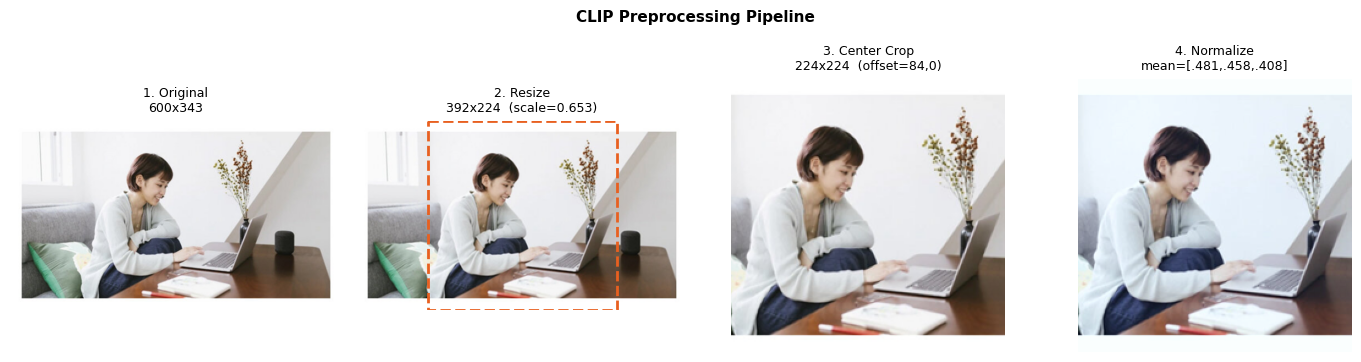

Crop offset: left=84px, top=0px  |  Final embedding: 512-d (L2-normalised)


In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def show_normalization(pil_img: Image.Image):
    """Visualize each CLIP preprocessing step."""
    if pil_img is None:
        print('No image loaded. Upload an image in Cell 5 first.')
        return

    # Step 1 — original
    orig = pil_img.convert('RGB')
    w, h = orig.size

    # Step 2 — resize (shortest side → 224)
    scale   = 224 / min(w, h)
    rw, rh  = round(w * scale), round(h * scale)
    resized = orig.resize((rw, rh), Image.BICUBIC)

    # Step 3 — center crop 224x224
    left    = (rw - 224) // 2
    top     = (rh - 224) // 2
    cropped = resized.crop((left, top, left+224, top+224))

    # Step 4 — pixel-normalised (visual only — values won't look meaningful)
    mean = np.array([0.48145466, 0.4578275,  0.40821073])
    std  = np.array([0.26862954, 0.26130258, 0.27577711])
    arr  = np.array(cropped).astype(np.float32) / 255.0
    normed = np.clip((arr - mean) / std, -2, 2)  # clip for display
    normed_vis = (normed - normed.min()) / (normed.max() - normed.min() + 1e-8)

    fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
    steps = [
        (orig,       f'1. Original\n{w}x{h}'),
        (resized,    f'2. Resize\n{rw}x{rh}  (scale={scale:.3f})'),
        (cropped,    f'3. Center Crop\n224x224  (offset={left},{top})'),
        (normed_vis, '4. Normalize\nmean=[.481,.458,.408]'),
    ]
    for ax, (img, title) in zip(axes, steps):
        ax.imshow(img if isinstance(img, np.ndarray) else img)
        ax.set_title(title, fontsize=9)
        ax.axis('off')

    # Highlight crop box on resized image
    axes[1].add_patch(patches.Rectangle(
        (left, top), 224, 224,
        linewidth=2, edgecolor='#E86020', facecolor='none', linestyle='--'
    ))
    plt.suptitle('CLIP Preprocessing Pipeline', fontsize=11, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('clip_preprocessing.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Crop offset: left={left}px, top={top}px  |  Final embedding: 512-d (L2-normalised)')


# Run on current image from Cell 5
show_normalization(_state.get('pil'))

---
## Cell 7 — Reference-free metrics (No Ground-Truth)

Compute quality metrics that do **not** require reference captions.

In [11]:
def compute_no_gt_metrics(caption: str = None, pil_img: Image.Image = None):
    """Compute CLIPScore, Perplexity, and Grammar Score for the given caption."""
    cap = caption or _state.get('caption')
    img = pil_img  or _state.get('pil')

    if cap is None:
        print('No caption available. Run Cell 5 to generate one first.')
        return
    if img is None:
        print('No image available. Upload an image in Cell 5 first.')
        return

    print(f'Caption: "{cap}"')
    print()

    print('Computing CLIPScore ...')
    cs = clip_score(img, cap)

    print('Computing Perplexity ...')
    ppl = perplexity(cap)

    gs  = grammar_score(cap)

    display(HTML(f"""
<table style='border-collapse:collapse;width:480px;font-family:monospace;font-size:13px'>
<tr style='background:#0B6E4F;color:white'>
  <th style='padding:7px 14px;text-align:left'>Metric</th>
  <th style='padding:7px 14px;text-align:left'>Value</th>
  <th style='padding:7px 14px;text-align:left'>Note</th>
</tr>
<tr style='background:#f4f8f6'>
  <td style='padding:6px 14px'>CLIPScore</td>
  <td style='padding:6px 14px;font-weight:bold;color:#0B6E4F'>{cs:.1f} / 100</td>
  <td style='padding:6px 14px;color:#666'>Human threshold ~67</td>
</tr>
<tr>
  <td style='padding:6px 14px'>Perplexity (GPT-2)</td>
  <td style='padding:6px 14px;font-weight:bold;color:#0D1B2A'>{ppl:.1f}</td>
  <td style='padding:6px 14px;color:#666'>Lower = more fluent (good: 20–80)</td>
</tr>
<tr style='background:#f4f8f6'>
  <td style='padding:6px 14px'>Grammar Score</td>
  <td style='padding:6px 14px;font-weight:bold;color:#C55A11'>{gs:.0f}%</td>
  <td style='padding:6px 14px;color:#666'>Heuristic: length, verbs, repetition</td>
</tr>
</table>
"""))


# Run on current state
compute_no_gt_metrics()

Caption: "a woman sitting on a desk with a laptop on her lap."

Computing CLIPScore ...
Computing Perplexity ...
Loading Frozen ...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Frozen loaded.


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Metric,Value,Note
CLIPScore,28.8 / 100,Human threshold ~67
Perplexity (GPT-2),17.6,Lower = more fluent (good: 20–80)
Grammar Score,100%,"Heuristic: length, verbs, repetition"


---
## Cell 8 — Reference-based metrics (Ground-Truth)

Paste your reference captions below (one per line), then run the cell.

In [12]:
# ── Edit this list with your reference captions ──────────────────────────────
REFERENCES = [
    "cars are parked in a parking lot on the side of the road"
]
# ─────────────────────────────────────────────────────────────────────────────

def compute_gt_metrics(caption: str = None, references: list = None):
    cap  = caption    or _state.get('caption')
    refs = references or REFERENCES

    if cap is None:
        print('No caption. Generate one in Cell 5 first.')
        return
    if not refs or not any(r.strip() for r in refs):
        print('No reference captions. Edit the REFERENCES list above.')
        return

    refs = [r.strip() for r in refs if r.strip()]
    print(f'Caption  : "{cap}"')
    print(f'References ({len(refs)}):')
    for i, r in enumerate(refs, 1):
        print(f'  [{i}] "{r}"')
    print()

    b1  = bleu_n(cap, refs, 1)
    b4  = bleu_n(cap, refs, 4)
    met = meteor_score(cap, refs)
    rl  = rouge_l(cap, refs)

    display(HTML(f"""
<table style='border-collapse:collapse;width:520px;font-family:monospace;font-size:13px'>
<tr style='background:#0D1B2A;color:white'>
  <th style='padding:7px 14px;text-align:left'>Metric</th>
  <th style='padding:7px 14px;text-align:right'>Score</th>
  <th style='padding:7px 14px;text-align:left'>Description</th>
</tr>
<tr style='background:#f4f7fc'>
  <td style='padding:6px 14px'>BLEU-1</td>
  <td style='padding:6px 14px;text-align:right;font-weight:bold'>{b1:.4f}</td>
  <td style='padding:6px 14px;color:#555'>Unigram precision</td>
</tr>
<tr>
  <td style='padding:6px 14px'>BLEU-4</td>
  <td style='padding:6px 14px;text-align:right;font-weight:bold'>{b4:.4f}</td>
  <td style='padding:6px 14px;color:#555'>4-gram precision (main BLEU metric)</td>
</tr>
<tr style='background:#f4f7fc'>
  <td style='padding:6px 14px'>METEOR</td>
  <td style='padding:6px 14px;text-align:right;font-weight:bold'>{met:.4f}</td>
  <td style='padding:6px 14px;color:#555'>Unigram F-score (approx.)</td>
</tr>
<tr>
  <td style='padding:6px 14px'>ROUGE-L</td>
  <td style='padding:6px 14px;text-align:right;font-weight:bold'>{rl:.4f}</td>
  <td style='padding:6px 14px;color:#555'>LCS-based F-score</td>
</tr>
</table>
<p style='font-size:11px;color:#999;margin-top:6px'>Note: METEOR uses unigram overlap (no WordNet). Install <code>nltk</code> for full METEOR.</p>
"""))


compute_gt_metrics()

Caption  : "a woman sitting on a desk with a laptop on her lap."
References (1):
  [1] "cars are parked in a parking lot on the side of the road"



Metric,Score,Description
BLEU-1,0.1415,Unigram precision
BLEU-4,0.0920,4-gram precision (main BLEU metric)
METEOR,0.1709,Unigram F-score (approx.)
ROUGE-L,0.1600,LCS-based F-score


---
## Cell 9 — Compare all models and strategies on the current image

In [13]:
def compare_all(references: list = None):
    """
    Generate captions from all 3 models x 3 strategies (9 configs)
    on the current image and display a comparison table.
    """
    if _state['pil'] is None:
        print('Upload an image in Cell 5 first.')
        return

    if _state['emb'] is None:
        print('Encoding image ...')
        _state['emb'] = encode_image(_state['pil'])

    refs = [r.strip() for r in (references or REFERENCES) if r.strip()]
    configs = [
        ('Frozen', 'beam'),   ('Frozen', 'greedy'), ('Frozen', 'nucleus'),
        ('FT-4L',  'beam'),   ('FT-4L',  'greedy'), ('FT-4L',  'nucleus'),
        ('LoRA',   'beam'),   ('LoRA',   'greedy'), ('LoRA',   'nucleus'),
    ]
    results = []
    for model_name, strategy in configs:
        print(f'  {model_name} / {strategy} ...', end='', flush=True)
        t0  = time.time()
        m   = get_model(model_name)
        cap = m.generate(_state['emb'], strategy=strategy)
        t   = time.time() - t0
        b4  = bleu_n(cap, refs, 4) if refs else None
        rl  = rouge_l(cap, refs)   if refs else None
        results.append((model_name, strategy, cap, t, b4, rl))
        print(f' {t:.1f}s')

    # Build HTML table
    ref_cols = '<th>BLEU-4</th><th>ROUGE-L</th>' if refs else ''
    rows = ''
    for i, (mn, st, cap, t, b4, rl) in enumerate(results):
        bg    = '#f4f8f6' if i % 2 == 0 else 'white'
        ref_v = f'<td>{b4:.4f}</td><td>{rl:.4f}</td>' if refs else ''
        rows += f"""
<tr style='background:{bg}'>
  <td style='padding:6px 12px;font-weight:bold'>{mn}</td>
  <td style='padding:6px 12px'>{st}</td>
  <td style='padding:6px 12px;font-style:italic'>&ldquo;{cap}&rdquo;</td>
  <td style='padding:6px 12px;text-align:right'>{t:.1f}s</td>
  {ref_v}
</tr>"""

    display(HTML(f"""
<table style='border-collapse:collapse;width:100%;font-family:sans-serif;font-size:12px'>
<tr style='background:#0D1B2A;color:white'>
  <th style='padding:8px 12px;text-align:left'>Model</th>
  <th style='padding:8px 12px;text-align:left'>Strategy</th>
  <th style='padding:8px 12px;text-align:left'>Caption</th>
  <th style='padding:8px 12px'>Time</th>
  {ref_cols}
</tr>
{rows}
</table>
"""))


# Run — will skip ref metrics if REFERENCES list is empty
compare_all()

  Frozen / beam ... 1.0s
  Frozen / greedy ... 1.1s
  Frozen / nucleus ... 0.5s
  FT-4L / beam ...Loading FT-4L ...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

FT-4L loaded.
 3.7s
  FT-4L / greedy ... 0.6s
  FT-4L / nucleus ... 0.8s
  LoRA / beam ... 1.1s
  LoRA / greedy ... 0.6s
  LoRA / nucleus ... 0.7s


Model,Strategy,Caption,Time,BLEU-4,ROUGE-L
Frozen,beam,“a woman sitting next to a laptop on a desk.”,1.0s,0.0926,0.1739
Frozen,greedy,“allow her to open a laptop.”,1.1s,0.0779,0.1053
Frozen,nucleus,"“allow a woman to sit on the counter next, and her laptop is sitting there.”",0.5s,0.0769,0.2143
FT-4L,beam,“a woman sitting at a desk with a laptop.”,3.7s,0.0916,0.0909
FT-4L,greedy,“a woman sitting on a couch using her laptop.”,0.6s,0.0916,0.1818
FT-4L,nucleus,“a woman sits on a desk using her laptop.”,0.8s,0.0916,0.1818
LoRA,beam,“a woman sitting on a desk with a laptop on her lap.”,1.1s,0.0920,0.1600
LoRA,greedy,"“201c0d8b-a4f7e6) .jpg (14 KB, 496x480 pixels).”",0.6s,0.0779,0.0000
LoRA,nucleus,"“201c0d8f-e4b6a3-4800 , a woman looks at her laptop on the table.”",0.7s,0.0926,0.2500
